# Credit Card Evaluation


In [2]:
import warnings

warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

from sklearn.metrics import average_precision_score, roc_auc_score, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, SGDClassifier

In [3]:
RANDOM_STATE = 1337

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "padme" / "src" / "main" / "resources" / "data"
OUT_DIR = DATA_DIR / "output/credit_card"

TRAIN_PATH = DATA_DIR / "input" / "creditcard_train.csv"
TEST_PATH = OUT_DIR / "creditcard_test.csv"

MODES = ["baseline", "padme", "random"]

NODES = 8
BASELINE_NODE = 0

RATIOS = [0.01, 0.02, 0.03, 0.04, 0.05, 0.08, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

DROP_COLS = ["__id", "label"]
LABEL_COL = "label"


In [4]:
def ratio_to_int(r: float) -> int:
    return int(round(r * 100))

def load_csv_any(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Not found: {path}")
    return pd.read_csv(path)

def load_test(train_csv: Path, test_csv: Path):
    if not test_csv.exists():
        raise FileNotFoundError(f"Required test set not found: {test_csv}. ")

    df_train = load_csv_any(train_csv)
    df_test = load_csv_any(test_csv)

    y_train = df_train[LABEL_COL].astype(int).to_numpy()
    X_train = df_train.drop(columns=[c for c in [LABEL_COL] + DROP_COLS if c in df_train.columns])

    y_test = df_test[LABEL_COL].astype(int).to_numpy()
    X_test = df_test.drop(columns=[c for c in [LABEL_COL] + DROP_COLS if c in df_test.columns])

    return X_train, y_train, X_test, y_test

X_train_full, y_train_full, X_test, y_test = load_test(TRAIN_PATH, TEST_PATH)

feature_cols = list(X_train_full.columns)

print("Train full:", X_train_full.shape, "Test:", X_test.shape, "Pos rate test:", float(np.mean(y_test)))

Train full: (20000, 30) Test: (4000, 30) Pos rate test: 0.05


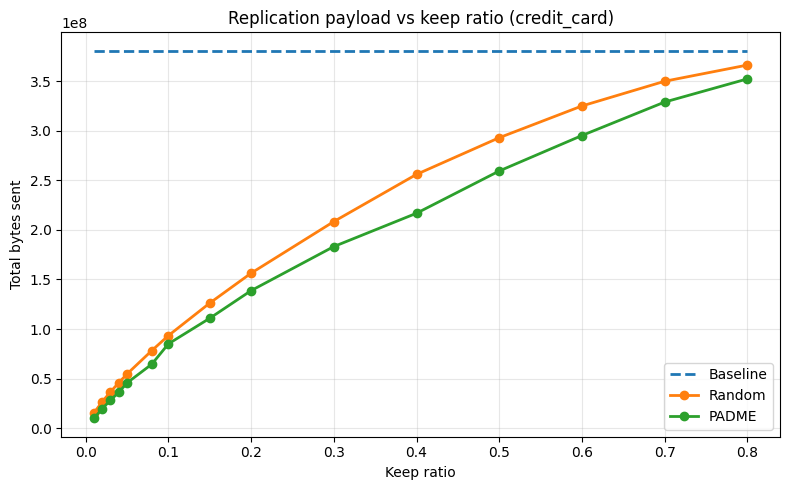

In [5]:
def load_metrics_json(path):
    p = Path(path)
    if not p.exists():
        return None
    with open(p, "r", encoding="utf-8") as f:
        return json.load(f)


def load_network_bytes_series(output_root: Path):
    output_root = Path(output_root)

    baseline_metrics = load_metrics_json(output_root / "baseline" / "metrics.json")
    baseline_bytes = None if baseline_metrics is None else baseline_metrics["totalBytesSent"]

    def load_mode_series(mode: str):
        mode_dir = output_root / mode
        if not mode_dir.exists():
            return [], []

        pairs = []
        for child in mode_dir.iterdir():
            if not child.is_dir():
                continue
            metrics = load_metrics_json(child / "metrics.json")
            if metrics is None:
                continue
            pairs.append((float(metrics["keepRatio"]), int(metrics["totalBytesSent"])))

        pairs.sort(key=lambda x: x[0])
        ratios = [x[0] for x in pairs]
        bytes_sent = [x[1] for x in pairs]
        return ratios, bytes_sent

    random_ratios, random_bytes = load_mode_series("random")
    padme_ratios, padme_bytes = load_mode_series("padme")

    return baseline_bytes, random_ratios, random_bytes, padme_ratios, padme_bytes


def plot_network_bytes_vs_keep_ratio(output_root, title=None):
    output_root = Path(output_root)

    baseline_bytes, random_ratios, random_bytes, padme_ratios, padme_bytes = load_network_bytes_series(output_root)

    plt.figure(figsize=(8, 5))

    if baseline_bytes is not None:
        x_for_line = sorted(set(random_ratios + padme_ratios))
        if not x_for_line:
            x_for_line = [0.0, 1.0]
        plt.plot(
            x_for_line,
            [baseline_bytes] * len(x_for_line),
            linestyle="--",
            linewidth=2,
            label="Baseline"
        )

    if random_ratios:
        plt.plot(
            random_ratios,
            random_bytes,
            marker="o",
            linewidth=2,
            label="Random"
        )

    if padme_ratios:
        plt.plot(
            padme_ratios,
            padme_bytes,
            marker="o",
            linewidth=2,
            label="PADME"
        )

    plt.xlabel("Keep ratio")
    plt.ylabel("Total bytes sent")
    plt.title(title or f"Replication payload vs keep ratio ({output_root.name})")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_network_bytes_vs_keep_ratio(OUT_DIR)

In [6]:
def node_file(mode: str, ratio_int: int | None, node_idx: int) -> Path:
    if mode == "baseline":
        return OUT_DIR / "baseline" / f"baseline_node{node_idx}.csv"
    return OUT_DIR / mode / str(ratio_int) / f"{mode}_node{node_idx}.csv"

def load_node_dataset(mode: str, ratio: float | None, node_idx: int):
    r_int = None if ratio is None else ratio_to_int(ratio)
    p = node_file(mode, r_int, node_idx)

    df = load_csv_any(p)
    if LABEL_COL not in df.columns:
        raise ValueError(f"{p} does not have column '{LABEL_COL}'.")

    y = df[LABEL_COL].astype(int).to_numpy()
    X = df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors="ignore")
    X = X.reindex(columns=feature_cols, fill_value=0.0)

    return X, y, str(p)

def pr_auc(model, Xtr, ytr, Xte, yte) -> float:
    model.fit(Xtr, ytr)
    if hasattr(model, "predict_proba"):
        p = model.predict_proba(Xte)[:, 1]
    else:
        s = model.decision_function(Xte)
        p = 1 / (1 + np.exp(-s))
    return float(average_precision_score(yte, p))

In [7]:
stats_rows = []

for mode in ["baseline", "random", "padme"]:
    if mode == "baseline":
        ratios_to_check = [None]
    else:
        ratios_to_check = RATIOS

    for r in ratios_to_check:
        for i in range(NODES):
            Xn, yn, pn = load_node_dataset(mode, r, i)

            yn_series = pd.Series(yn)
            pos = int((yn_series == 1).sum())
            neg = int((yn_series == 0).sum())
            total = int(len(yn_series))

            stats_rows.append({
                "mode": mode,
                "keep_ratio": 1.0 if r is None else float(r),
                "ratio_int": 100 if r is None else ratio_to_int(r),
                "node": i,
                "rows": total,
                "positives": pos,
                "negatives": neg,
                "positive_ratio": (pos / total) if total > 0 else np.nan,
                "file": str(pn)
            })

stats_df = pd.DataFrame(stats_rows).sort_values(
    ["mode", "keep_ratio", "node"]
).reset_index(drop=True)

stats_df

,mode,keep_ratio,ratio_int,node,rows,positives,negatives,positive_ratio,file
0,baseline,1.0,100,0,19963,289,19674,0.014477,C:\Users\Legion\Desktop\FEUP\Dissertação\PADME...
1,baseline,1.0,100,1,19988,290,19698,0.014509,C:\Users\Legion\Desktop\FEUP\Dissertação\PADME...
2,baseline,1.0,100,2,19976,290,19686,0.014517,C:\Users\Legion\Desktop\FEUP\Dissertação\PADME...
3,baseline,1.0,100,3,19974,290,19684,0.014519,C:\Users\Legion\Desktop\FEUP\Dissertação\PADME...
4,baseline,1.0,100,4,20000,290,19710,0.014500,C:\Users\Legion\Desktop\FEUP\Dissertação\PADME...
...,...,...,...,...,...,...,...,...,...
243,random,0.8,80,3,16000,226,15774,0.014125,C:\Users\Legion\Desktop\FEUP\Dissertação\PADME...
244,random,0.8,80,4,16000,235,15765,0.014687,C:\Users\Legion\Desktop\FEUP\Dissertação\PADME...
245,random,0.8,80,5,16000,229,15771,0.014313,C:\Users\Legion\Desktop\FEUP\Dissertação\PADME...
246,random,0.8,80,6,16000,235,15765,0.014687,C:\Users\Legion\Desktop\FEUP\Dissertação\PADME...


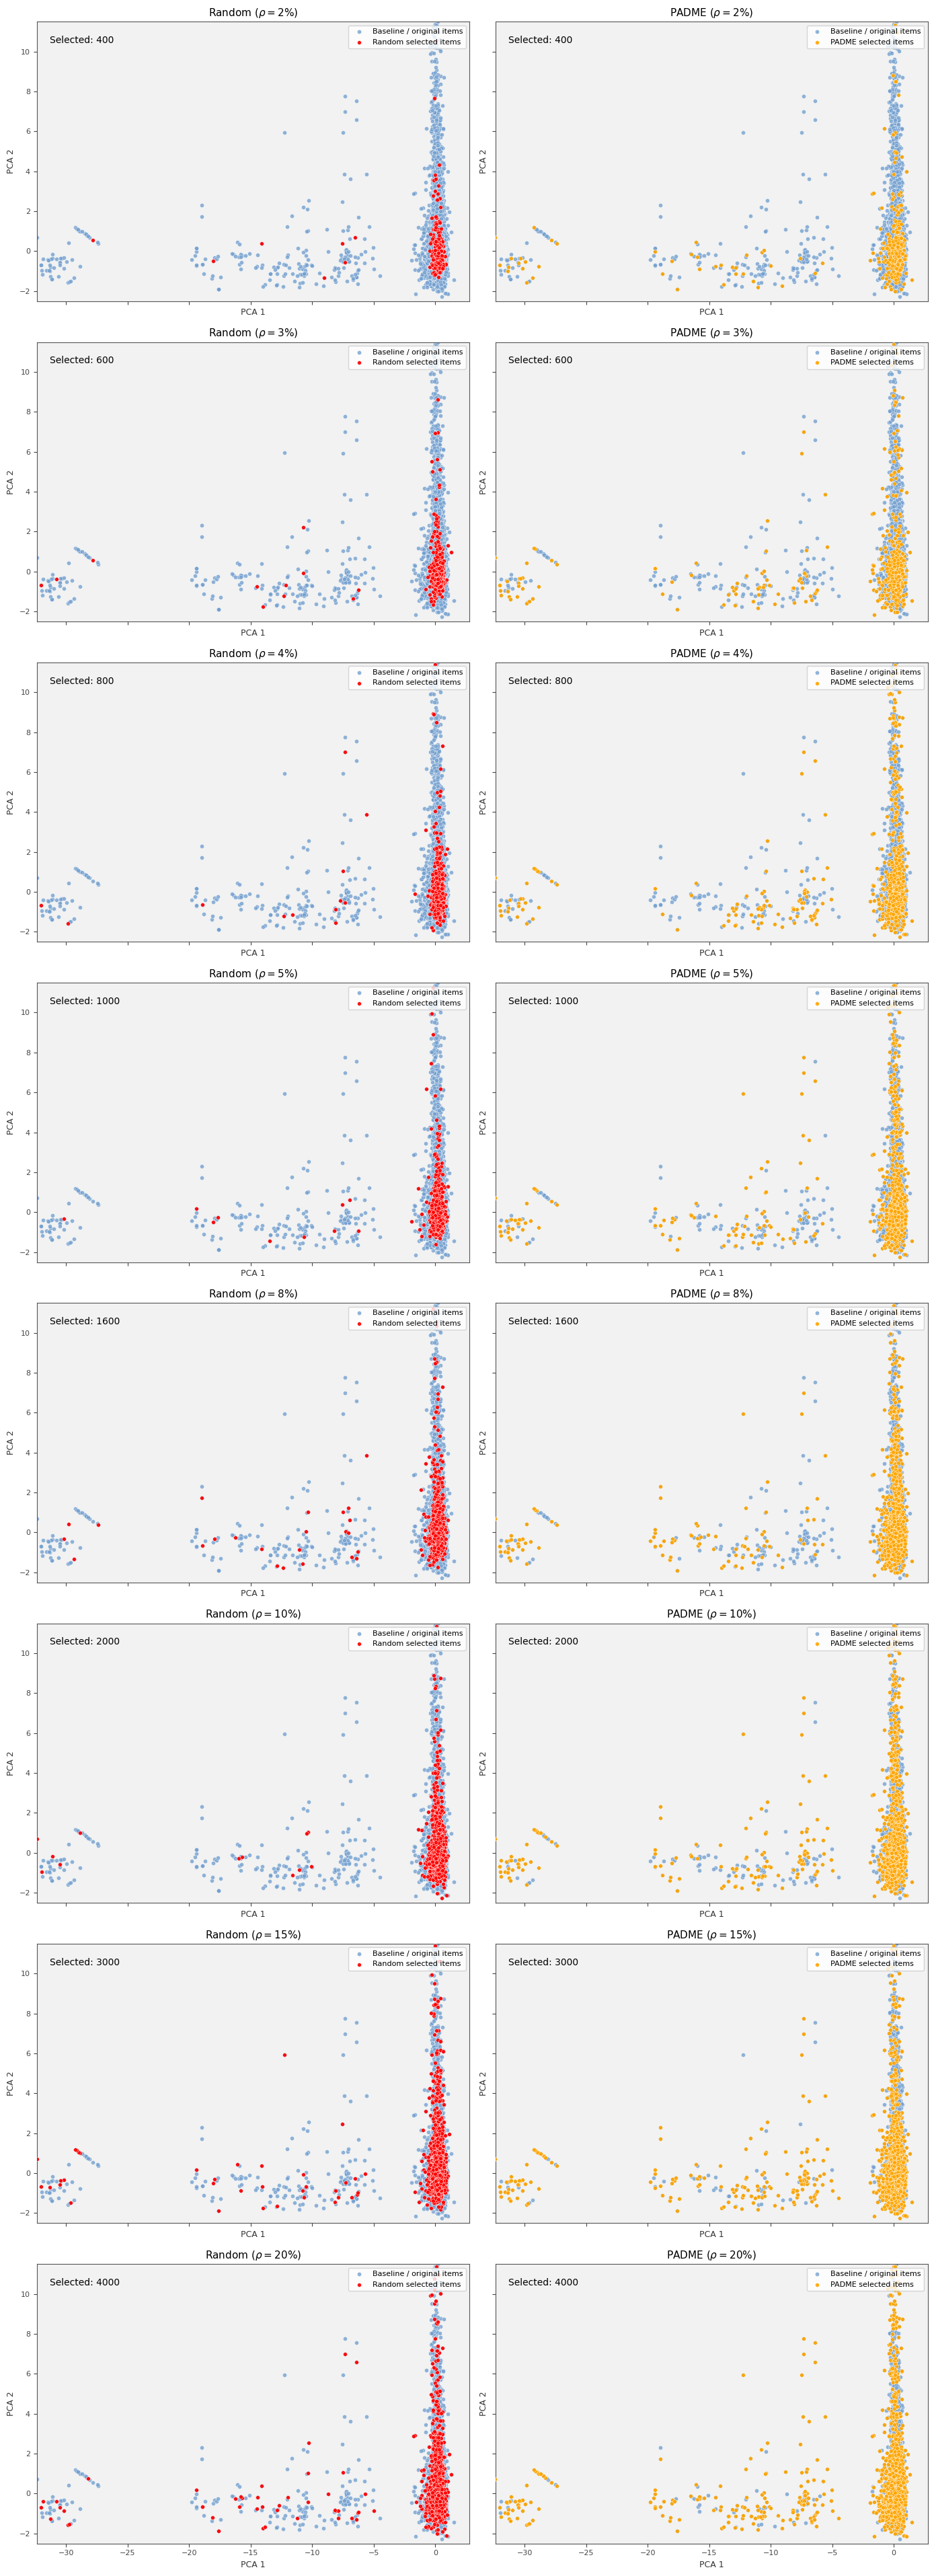

In [8]:
from matplotlib import rcParams

plt.rcdefaults()
plt.style.use("default")

rcParams["figure.facecolor"] = "white"
rcParams["axes.facecolor"] = "#f5f5f5"
rcParams["savefig.facecolor"] = "white"
rcParams["text.color"] = "black"
rcParams["axes.labelcolor"] = "black"
rcParams["axes.edgecolor"] = "#444444"
rcParams["xtick.color"] = "#444444"
rcParams["ytick.color"] = "#444444"
rcParams["legend.facecolor"] = "white"
rcParams["legend.edgecolor"] = "#cccccc"

baseline_path = OUT_DIR / "baseline" / "baseline_node0.csv"


def _load_geom_matrix(path):
    df = load_csv_any(path)
    X = df.drop(columns=[c for c in [LABEL_COL] + DROP_COLS if c in df.columns], errors="ignore")
    X = X.reindex(columns=feature_cols, fill_value=0.0)
    X = X.select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return df, X


def _fit_pca_reference(X_base):
    Xb = X_base.to_numpy(dtype=float)
    scaler = StandardScaler()
    Xb_scaled = scaler.fit_transform(Xb)
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    B = pca.fit_transform(Xb_scaled)
    return scaler, pca, B


def _project_subset(X, scaler, pca):
    Xs = X.to_numpy(dtype=float)
    Xs_scaled = scaler.transform(Xs)
    Z = pca.transform(Xs_scaled)
    return Z


def _robust_limits(*arrays, low=0.5, high=99.5, pad=0.06):
    x = np.concatenate([a[:, 0] for a in arrays if len(a) > 0])
    y = np.concatenate([a[:, 1] for a in arrays if len(a) > 0])
    x0, x1 = np.percentile(x, [low, high])
    y0, y1 = np.percentile(y, [low, high])
    dx = max(1e-9, x1 - x0)
    dy = max(1e-9, y1 - y0)
    return ((x0 - pad * dx, x1 + pad * dx), (y0 - pad * dy, y1 + pad * dy))


def _draw_panel(ax, B, S, title, selected_label, selected_color, xlim, ylim, base_s, selected_s):
    ax.set_facecolor("#f2f2f2")

    ax.scatter(
        B[:, 0], B[:, 1],
        s=base_s,
        alpha=0.78,
        color="#729fcf",
        edgecolors="white",
        linewidths=0.35,
        label="Baseline / original items",
        zorder=1
    )

    ax.scatter(
        S[:, 0], S[:, 1],
        s=selected_s,
        alpha=0.92,
        color=selected_color,
        edgecolors="white",
        linewidths=0.35,
        label=selected_label,
        zorder=3
    )

    ax.text(
        0.03, 0.95,
        f"Selected: {len(S)}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        color="black"
    )

    ax.set_title(title, fontsize=11, color="black")
    ax.set_xlabel("PCA 1", fontsize=9, color="#333333")
    ax.set_ylabel("PCA 2", fontsize=9, color="#333333")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.grid(False)
    ax.tick_params(axis="both", labelsize=8, colors="#444444")
    ax.legend(frameon=True, loc="upper right", fontsize=8)

    for spine in ax.spines.values():
        spine.set_color("#555555")
        spine.set_linewidth(0.8)


def _available_ratios(mode_dir):
    ratios = []
    if not mode_dir.exists():
        return ratios
    for child in mode_dir.iterdir():
        if not child.is_dir():
            continue
        try:
            ratio_int = int(child.name)
            ratios.append(ratio_int / 100.0)
        except ValueError:
            pass
    return sorted(ratios)


def _node_file_for_ratio(mode, ratio):
    ratio_dir = OUT_DIR / mode / str(ratio_to_int(ratio))
    return ratio_dir / f"{mode}_node0.csv"


df_base, X_base = _load_geom_matrix(baseline_path)
scaler, pca, B = _fit_pca_reference(X_base)

random_ratios = set(_available_ratios(OUT_DIR / "random"))
padme_ratios = set(_available_ratios(OUT_DIR / "padme"))
target_ratios = [0.02, 0.03, 0.04, 0.05, 0.08, 0.10, 0.15, 0.20]
ratios = [r for r in target_ratios if r in random_ratios and r in padme_ratios]

proj_random = {}
proj_padme = {}
all_arrays = [B]

for ratio in ratios:
    random_path = _node_file_for_ratio("random", ratio)
    padme_path = _node_file_for_ratio("padme", ratio)

    if not random_path.exists() or not padme_path.exists():
        continue

    _, X_rand = _load_geom_matrix(random_path)
    _, X_padm = _load_geom_matrix(padme_path)

    R = _project_subset(X_rand, scaler, pca)
    P = _project_subset(X_padm, scaler, pca)

    proj_random[ratio] = R
    proj_padme[ratio] = P
    all_arrays.extend([R, P])

ratios = [r for r in ratios if r in proj_random and r in proj_padme]
xlim, ylim = _robust_limits(*all_arrays, low=0.5, high=99.5, pad=0.06)

n_rows = len(ratios)
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 4.8 * n_rows), sharex=True, sharey=True)
fig.patch.set_facecolor("white")

if n_rows == 1:
    axes = np.array([axes])

selected_s = 18
base_s = selected_s * 1.1

for i, ratio in enumerate(ratios):
    R = proj_random[ratio]
    P = proj_padme[ratio]
    pct = int(round(ratio * 100))

    _draw_panel(axes[i, 0], B, R, rf"Random ($\rho = {pct}\%$)", "Random selected items", "#FF0000", xlim, ylim, base_s, selected_s)
    _draw_panel(axes[i, 1], B, P, rf"PADME ($\rho = {pct}\%$)", "PADME selected items", "#FFA500", xlim, ylim, base_s, selected_s)

plt.tight_layout()
plt.show()

In [9]:
models = {
    "LogReg": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="saga",
            max_iter=5000,
            n_jobs=-1,
            random_state=RANDOM_STATE,
            class_weight="balanced"
        ))
    ])
}

In [10]:
def eval_auc_metrics(model, X_train, y_train, X_test, y_test):
    train_classes = np.unique(y_train)
    train_pos = int(np.sum(y_train == 1))
    train_neg = int(np.sum(y_train == 0))

    if len(train_classes) < 2:
        return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, False, train_pos, train_neg

    model.fit(X_train, y_train)
    p = model.predict_proba(X_test)[:, 1]
    pred = model.predict(X_test)

    pr_auc = average_precision_score(y_test, p)
    roc_auc = roc_auc_score(y_test, p)
    tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()

    return pr_auc, roc_auc, tp, fp, tn, fn, True, train_pos, train_neg


rows = []

for model_name, model in models.items():
    Xb, yb, pb = load_node_dataset("baseline", None, BASELINE_NODE)
    base_pr_auc, base_roc_auc, base_tp, base_fp, base_tn, base_fn, base_trained, base_pos, base_neg = eval_auc_metrics(
        model, Xb, yb, X_test, y_test
    )

    rows.append({
        "model": model_name,
        "mode": "baseline",
        "keep_ratio": 1.0,
        "ratio_int": 100,
        "node": BASELINE_NODE,
        "trained": base_trained,
        "train_pos": base_pos,
        "train_neg": base_neg,
        "tp": base_tp,
        "fp": base_fp,
        "tn": base_tn,
        "fn": base_fn,
        "pr_auc": base_pr_auc,
        "roc_auc": base_roc_auc,
        "pr_auc_mean": base_pr_auc,
        "pr_auc_std": 0.0,
        "roc_auc_mean": base_roc_auc,
        "roc_auc_std": 0.0,
        "valid_nodes": 1 if base_trained else 0,
        "invalid_nodes": 0 if base_trained else 1,
        "file": pb
    })

    for mode in ["random", "padme"]:
        for r in RATIOS:
            pr_scores = []
            roc_scores = []

            tp_sum = 0
            fp_sum = 0
            tn_sum = 0
            fn_sum = 0
            valid_nodes = 0
            invalid_nodes = 0
            train_pos_total = 0
            train_neg_total = 0

            for i in range(NODES):
                Xn, yn, pn = load_node_dataset(mode, r, i)
                pr_s, roc_s, tp, fp, tn, fn, fitted, train_pos, train_neg = eval_auc_metrics(model, Xn, yn, X_test, y_test)

                train_pos_total += train_pos
                train_neg_total += train_neg

                if fitted:
                    pr_scores.append(pr_s)
                    roc_scores.append(roc_s)

                    tp_sum += int(tp)
                    fp_sum += int(fp)
                    tn_sum += int(tn)
                    fn_sum += int(fn)
                    valid_nodes += 1
                else:
                    invalid_nodes += 1

                rows.append({
                    "model": model_name,
                    "mode": mode,
                    "keep_ratio": r,
                    "ratio_int": ratio_to_int(r),
                    "node": i,
                    "trained": fitted,
                    "train_pos": train_pos,
                    "train_neg": train_neg,
                    "tp": tp,
                    "fp": fp,
                    "tn": tn,
                    "fn": fn,
                    "pr_auc": pr_s,
                    "roc_auc": roc_s,
                    "file": pn
                })

            rows.append({
                "model": model_name,
                "mode": mode,
                "keep_ratio": r,
                "ratio_int": ratio_to_int(r),
                "node": "mean",
                "trained": valid_nodes,
                "train_pos": train_pos_total,
                "train_neg": train_neg_total,
                "tp": tp_sum if valid_nodes > 0 else np.nan,
                "fp": fp_sum if valid_nodes > 0 else np.nan,
                "tn": tn_sum if valid_nodes > 0 else np.nan,
                "fn": fn_sum if valid_nodes > 0 else np.nan,
                "pr_auc": float(np.mean(pr_scores)) if valid_nodes > 0 else np.nan,
                "roc_auc": float(np.mean(roc_scores)) if valid_nodes > 0 else np.nan,
                "pr_auc_mean": float(np.mean(pr_scores)) if valid_nodes > 0 else np.nan,
                "pr_auc_std": float(np.std(pr_scores, ddof=1)) if valid_nodes > 1 else 0.0 if valid_nodes == 1 else np.nan,
                "roc_auc_mean": float(np.mean(roc_scores)) if valid_nodes > 0 else np.nan,
                "roc_auc_std": float(np.std(roc_scores, ddof=1)) if valid_nodes > 1 else 0.0 if valid_nodes == 1 else np.nan,
                "valid_nodes": valid_nodes,
                "invalid_nodes": invalid_nodes
            })

results = pd.DataFrame(rows)

results[(results["node"] == "mean") | (results["mode"] == "baseline")].sort_values(["model", "mode", "keep_ratio"])

,model,mode,keep_ratio,ratio_int,node,trained,train_pos,train_neg,tp,fp,...,fn,pr_auc,roc_auc,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,valid_nodes,invalid_nodes,file
0,LogReg,baseline,1.00,100,0,True,289,19674,181,98,...,19,0.900417,0.977217,0.900417,0.000000,0.977217,0.000000,1.0,0.0,C:\Users\Legion\Desktop\FEUP\Dissertação\PADME...
144,LogReg,padme,0.01,1,mean,8,309,1291,1253,99,...,347,0.847594,0.937194,0.847594,0.015910,0.937194,0.011352,8.0,0.0,NaN
153,LogReg,padme,0.02,2,mean,8,456,2744,1305,224,...,295,0.864845,0.948927,0.864845,0.017063,0.948927,0.008670,8.0,0.0,NaN
162,LogReg,padme,0.03,3,mean,8,707,4093,1338,121,...,262,0.887723,0.963821,0.887723,0.008685,0.963821,0.007457,8.0,0.0,NaN
171,LogReg,padme,0.04,4,mean,8,737,5663,1331,96,...,269,0.882532,0.956962,0.882532,0.007562,0.956962,0.005560,8.0,0.0,NaN
180,LogReg,padme,0.05,5,mean,8,871,7129,1335,168,...,265,0.881198,0.958608,0.881198,0.009087,0.958608,0.003448,8.0,0.0,NaN
189,LogReg,padme,0.08,8,mean,8,955,11845,1376,212,...,224,0.894968,0.967343,0.894968,0.008709,0.967343,0.006149,8.0,0.0,NaN
198,LogReg,padme,0.10,10,mean,8,1219,14781,1367,160,...,233,0.899700,0.970039,0.899700,0.007807,0.970039,0.005299,8.0,0.0,NaN
207,LogReg,padme,0.15,15,mean,8,1387,22613,1385,200,...,215,0.899530,0.970639,0.899530,0.004117,0.970639,0.002885,8.0,0.0,NaN
216,LogReg,padme,0.20,20,mean,8,1673,30327,1387,234,...,213,0.905264,0.975346,0.905264,0.001694,0.975346,0.001174,8.0,0.0,NaN


In [11]:
cm_mean = (
    results[
        results["node"].apply(lambda x: isinstance(x, (int, np.integer)))
    ][["model", "mode", "keep_ratio", "tp", "fp", "tn", "fn"]]
    .groupby(["model", "mode", "keep_ratio"], as_index=False)
    .mean()
)

cm_mean["precision"] = cm_mean["tp"] / (cm_mean["tp"] + cm_mean["fp"])
cm_mean["recall"] = cm_mean["tp"] / (cm_mean["tp"] + cm_mean["fn"])

cm_mean["precision"] = cm_mean["precision"].fillna(0.0)
cm_mean["recall"] = cm_mean["recall"].fillna(0.0)

cm_mean = cm_mean.sort_values(["model", "mode", "keep_ratio"]).reset_index(drop=True)

for model in cm_mean["model"].unique():
    print(f"\n=== {model} ===")
    sub_model = cm_mean[cm_mean["model"] == model]

    for mode in sub_model["mode"].unique():
        print(f"\n-- {mode} --")
        sub_mode = sub_model[sub_model["mode"] == mode]

        for _, r in sub_mode.iterrows():
            print(
                f"keep_ratio={r['keep_ratio']:.2f} | "
                f"tp={r['tp']:.1f} fp={r['fp']:.1f} tn={r['tn']:.1f} fn={r['fn']:.1f} | "
                f"precision={r['precision']:.4f} recall={r['recall']:.4f}"
            )


=== LogReg ===

-- baseline --
keep_ratio=1.00 | tp=181.0 fp=98.0 tn=3702.0 fn=19.0 | precision=0.6487 recall=0.9050

-- padme --
keep_ratio=0.01 | tp=156.6 fp=12.4 tn=3787.6 fn=43.4 | precision=0.9268 recall=0.7831
keep_ratio=0.02 | tp=163.1 fp=28.0 tn=3772.0 fn=36.9 | precision=0.8535 recall=0.8156
keep_ratio=0.03 | tp=167.2 fp=15.1 tn=3784.9 fn=32.8 | precision=0.9171 recall=0.8363
keep_ratio=0.04 | tp=166.4 fp=12.0 tn=3788.0 fn=33.6 | precision=0.9327 recall=0.8319
keep_ratio=0.05 | tp=166.9 fp=21.0 tn=3779.0 fn=33.1 | precision=0.8882 recall=0.8344
keep_ratio=0.08 | tp=172.0 fp=26.5 tn=3773.5 fn=28.0 | precision=0.8665 recall=0.8600
keep_ratio=0.10 | tp=170.9 fp=20.0 tn=3780.0 fn=29.1 | precision=0.8952 recall=0.8544
keep_ratio=0.15 | tp=173.1 fp=25.0 tn=3775.0 fn=26.9 | precision=0.8738 recall=0.8656
keep_ratio=0.20 | tp=173.4 fp=29.2 tn=3770.8 fn=26.6 | precision=0.8556 recall=0.8669
keep_ratio=0.30 | tp=175.1 fp=34.8 tn=3765.2 fn=24.9 | precision=0.8344 recall=0.8756
keep_rati

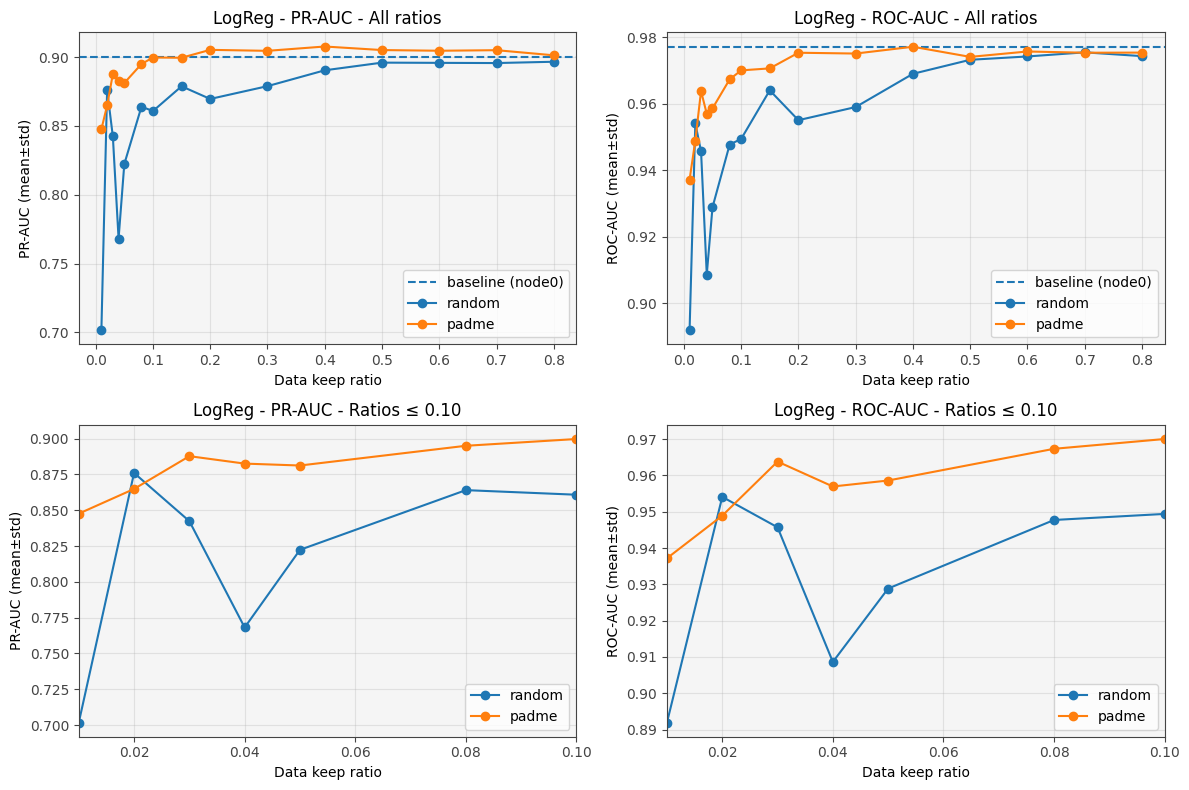

In [12]:
for model_name in models.keys():
    sub_mean = results[(results["model"] == model_name) & (results["node"] == "mean")].copy()
    base_row = results[(results["model"] == model_name) & (results["mode"] == "baseline")].iloc[0]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False)

    metrics = [
        ("pr_auc", "PR-AUC"),
        ("roc_auc", "ROC-AUC"),
    ]

    for col_idx, (metric_key, metric_label) in enumerate(metrics):
        ax = axes[0, col_idx]
        base = base_row[f"{metric_key}_mean"]
        ax.axhline(base, linestyle="--", label=f"baseline (node{BASELINE_NODE})")

        for mode in ["random", "padme"]:
            s = sub_mean[sub_mean["mode"] == mode].sort_values("keep_ratio")
            ax.errorbar(
                s["keep_ratio"],
                s[f"{metric_key}_mean"],
                # yerr=s[f"{metric_key}_std"],
                marker="o",
                capsize=3,
                label=mode
            )

        ax.set_xlabel("Data keep ratio")
        ax.set_ylabel(f"{metric_label} (mean±std)")
        ax.set_title(f"{model_name} - {metric_label} - All ratios")
        ax.legend()
        ax.grid(True, alpha=0.3)

        ax = axes[1, col_idx]
        sub_low = sub_mean[(sub_mean["mode"].isin(["random", "padme"])) & (sub_mean["keep_ratio"] <= 0.10)].copy()

        for mode in ["random", "padme"]:
            s = sub_low[sub_low["mode"] == mode].sort_values("keep_ratio")
            ax.errorbar(
                s["keep_ratio"],
                s[f"{metric_key}_mean"],
                # yerr=s[f"{metric_key}_std"],
                marker="o",
                capsize=3,
                label=mode
            )

        ax.set_xlim(sub_low["keep_ratio"].min(), 0.10)
        ax.set_xlabel("Data keep ratio")
        ax.set_ylabel(f"{metric_label} (mean±std)")
        ax.set_title(f"{model_name} - {metric_label} - Ratios ≤ 0.10")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()